In [84]:
#import
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import mesa
from mesa import Agent, Model
from mesa.time import BaseScheduler


In [85]:
# load data
CSV_PATH = r"C:\Users\Dev Sharma\OneDrive\Documents\MDP\Datasets\Single_AA1189.csv"
df = pd.read_csv(CSV_PATH)


In [86]:
# Split "lat,lon" string into two numeric columns
df[['lat', 'lon']] = df['Position'].str.split(',', expand=True).astype(float)
df['UTC'] = pd.to_datetime(df['UTC'])
df = df.sort_values('UTC').reset_index(drop=True)   # always sort by time!

print(f"CSV loaded: {len(df)} rows")
print(df[['UTC', 'lat', 'lon']].head())

CSV loaded: 600 rows
                        UTC        lat        lon
0 2026-02-07 17:10:56+00:00  36.128887 -86.671219
1 2026-02-07 17:25:29+00:00  36.128342 -86.671906
2 2026-02-07 17:30:16+00:00  36.127609 -86.677513
3 2026-02-07 17:30:25+00:00  36.127888 -86.677864
4 2026-02-07 17:30:33+00:00  36.128208 -86.678284


In [87]:
df.head()

,Timestamp,UTC,Callsign,Position,Altitude,Speed,Direction,lat,lon
0,1770484256,2026-02-07 17:10:56+00:00,AAL1189,"36.128887,-86.671219",0,0,84,36.128887,-86.671219
1,1770485129,2026-02-07 17:25:29+00:00,AAL1189,"36.128342,-86.671906",0,3,306,36.128342,-86.671906
2,1770485416,2026-02-07 17:30:16+00:00,AAL1189,"36.127609,-86.677513",0,0,312,36.127609,-86.677513
3,1770485425,2026-02-07 17:30:25+00:00,AAL1189,"36.127888,-86.677864",0,10,315,36.127888,-86.677864
4,1770485433,2026-02-07 17:30:33+00:00,AAL1189,"36.128208,-86.678284",0,12,315,36.128208,-86.678284


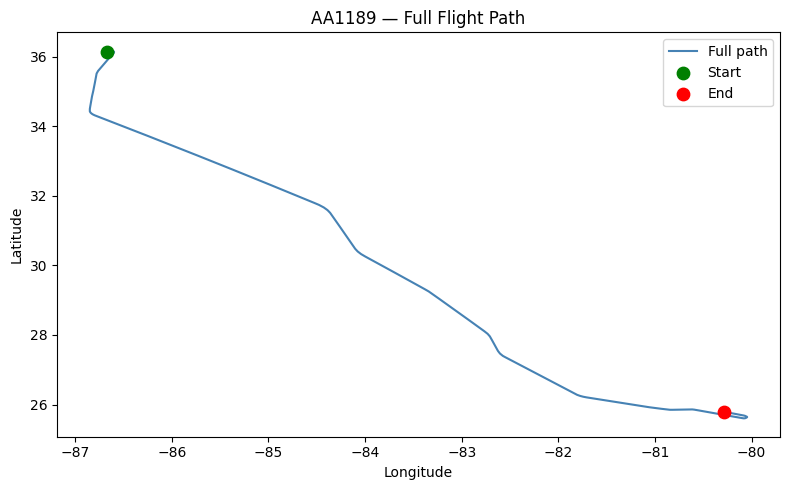

Static plot saved → static_path.png


In [88]:
plt.figure(figsize=(8, 5))
plt.plot(df['lon'], df['lat'], color='steelblue', linewidth=1.5, label='Full path')
plt.scatter(df['lon'].iloc[0],  df['lat'].iloc[0],  color='green', zorder=5, s=80, label='Start')
plt.scatter(df['lon'].iloc[-1], df['lat'].iloc[-1], color='red',   zorder=5, s=80, label='End')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('AA1189 — Full Flight Path')
plt.legend()
plt.tight_layout()
plt.savefig('static_path.png', dpi=150)
plt.show()
print("Static plot saved → static_path.png")


In [89]:
class AircraftAgent(Agent):
    """One aircraft that replays a recorded trajectory step by step."""
 
    def __init__(self, unique_id, model, trajectory: pd.DataFrame):
        super().__init__(unique_id, model)      # Mesa ka req.  #registers the agent

        self.trajectory  = trajectory.reset_index(drop=True) 
        self.step_index  = 0

        self.lat = self.trajectory['lat'].iloc[0]
        self.lon = self.trajectory['lon'].iloc[0]

        # needed for drawing the trail - later
        self.history_lat = [self.lat]
        self.history_lon = [self.lon]


        # state variables for an MDP - later
        self.altitude = self.trajectory['Altitude'].iloc[0]
        self.speed = self.trajectory['Speed'].iloc[0]
        self.heading = self.trajectory['Direction'].iloc[0]

 
    def step(self):
        """Advance one time step: move to next recorded position."""
        if self.step_index < len(self.trajectory) - 1:

            self.step_index += 1
            row = self.trajectory.iloc[self.step_index]

            self.lat = row.lat
            self.lon = row.lon

            self.history_lat.append(self.lat)
            self.history_lon.append(self.lon)

            self.altitude = row.Altitude
            self.speed = row.Speed
            self.heading = row.Direction

In [97]:
class AirTrafficModel(Model):
    """Airspace model containing one aircraft agent."""
 
    def __init__(self, data: pd.DataFrame):

        super().__init__() # Mesa req.

        self.schedule = BaseScheduler(self)

        self.aircraft = AircraftAgent(1, self, data)

        self.schedule.add(self.aircraft)
        
        self.time = 0   # simulation clock


    def step(self):
        self.schedule.step()
        self.time += 1

In [91]:
import mesa
mesa.__version__

'1.2.1'

In [92]:
model = AirTrafficModel(df)

agent = model.aircraft
n_steps = len(df)

for _ in range(n_steps - 1):
    model.step()

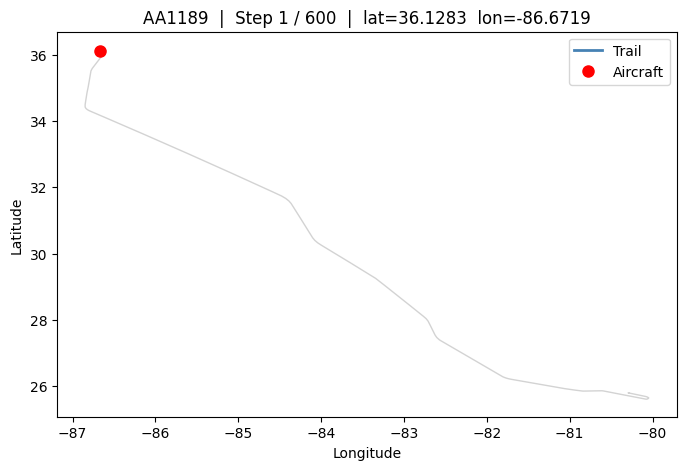

In [93]:
# ── 6. ANIMATED 2D VISUALIZATION ─────────────────────────────
# Re-run model fresh for clean animation
model = AirTrafficModel(df)
agent = model.aircraft
 
fig, ax = plt.subplots(figsize=(8, 5))
plt.ion()   # interactive mode on
 
# Pre-draw full ghost path (light grey background)
ax.plot(df['lon'], df['lat'], color='lightgrey', linewidth=1, zorder=1)
 
trail_line,  = ax.plot([], [], color='steelblue', linewidth=2, zorder=2, label='Trail')
plane_dot,   = ax.plot([], [], 'ro', markersize=8, zorder=3, label='Aircraft')
 
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('AA1189 — Live Simulation')
ax.legend()
 
STEP = 5   # animate every Nth point (set to 1 for full detail, higher = faster)
 
for i in range(0, n_steps - 1, STEP):
    model.step()
    trail_line.set_data(agent.history_lon, agent.history_lat)
    plane_dot.set_data([agent.lon], [agent.lat])
    ax.set_title(f"AA1189  |  Step {agent.step_index} / {n_steps}  |  "
                 f"lat={agent.lat:.4f}  lon={agent.lon:.4f}")
    plt.pause(0.01)
 
plt.ioff()
# plt.savefig('animated_final_frame.png', dpi=150)
plt.show()

# geo visualization 
ai

In [94]:
import pandas as pd
import plotly.graph_objects as go

# ── LOAD DATA ────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\Dev Sharma\OneDrive\Documents\MDP\Datasets\Single_AA1189.csv")
df[['lat', 'lon']] = df['Position'].str.split(',', expand=True).astype(float)
df['UTC'] = pd.to_datetime(df['UTC'])
df = df.sort_values('UTC').reset_index(drop=True)

# ── BUILD FIGURE ─────────────────────────────────────────────
fig = go.Figure()

# Flight path — colored by altitude
fig.add_trace(go.Scattergeo(
    lat=df['lat'],
    lon=df['lon'],
    mode='lines+markers',
    line=dict(width=2, color='rgba(100,180,255,0.4)'),
    marker=dict(
        size=4,
        color=df['Altitude'],
        colorscale='Viridis',
        colorbar=dict(title='Altitude (ft)'),
        showscale=True,
    ),
    text=[f"Time: {r.UTC}<br>Alt: {r.Altitude} ft<br>Speed: {r.Speed} kts" for _, r in df.iterrows()],
    hoverinfo='text',
    name='Flight Path',
))

# Start dot
fig.add_trace(go.Scattergeo(
    lat=[df['lat'].iloc[0]],
    lon=[df['lon'].iloc[0]],
    mode='markers+text',
    marker=dict(size=14, color='green'),
    text=['Departure'],
    textposition='top right',
    name='Start',
))

# End dot
fig.add_trace(go.Scattergeo(
    lat=[df['lat'].iloc[-1]],
    lon=[df['lon'].iloc[-1]],
    mode='markers+text',
    marker=dict(size=14, color='red'),
    text=['Arrival'],
    textposition='bottom right',
    name='End',
))

# ── MAP STYLE ────────────────────────────────────────────────
fig.update_geos(
    projection=dict(type='orthographic', rotation=dict(
        lon=(df['lon'].max() + df['lon'].min()) / 2,
        lat=(df['lat'].max() + df['lat'].min()) / 2,
    )),
    showland=True,    landcolor='#1a1a2e',
    showocean=True,   oceancolor='#0a0a1a',
    showlakes=True,   lakecolor='#0a0a1a',
    showcountries=True, countrycolor='grey',
    showcoastlines=True, coastlinecolor='steelblue',
    lonaxis=dict(range=[df['lon'].min() - 3, df['lon'].max() + 3]),
    lataxis=dict(range=[df['lat'].min() - 3, df['lat'].max() + 3]),
)

fig.update_layout(
    title='AA1189 — 3D Flight Trajectory (Plotly)',
    paper_bgcolor='#04080f',
    height=700,
)

# ── SAVE AND OPEN ────────────────────────────────────────────
fig.write_html('flight_plotly.html')

import webbrowser, os
webbrowser.open('file://' + os.path.abspath('flight_plotly.html'))

True

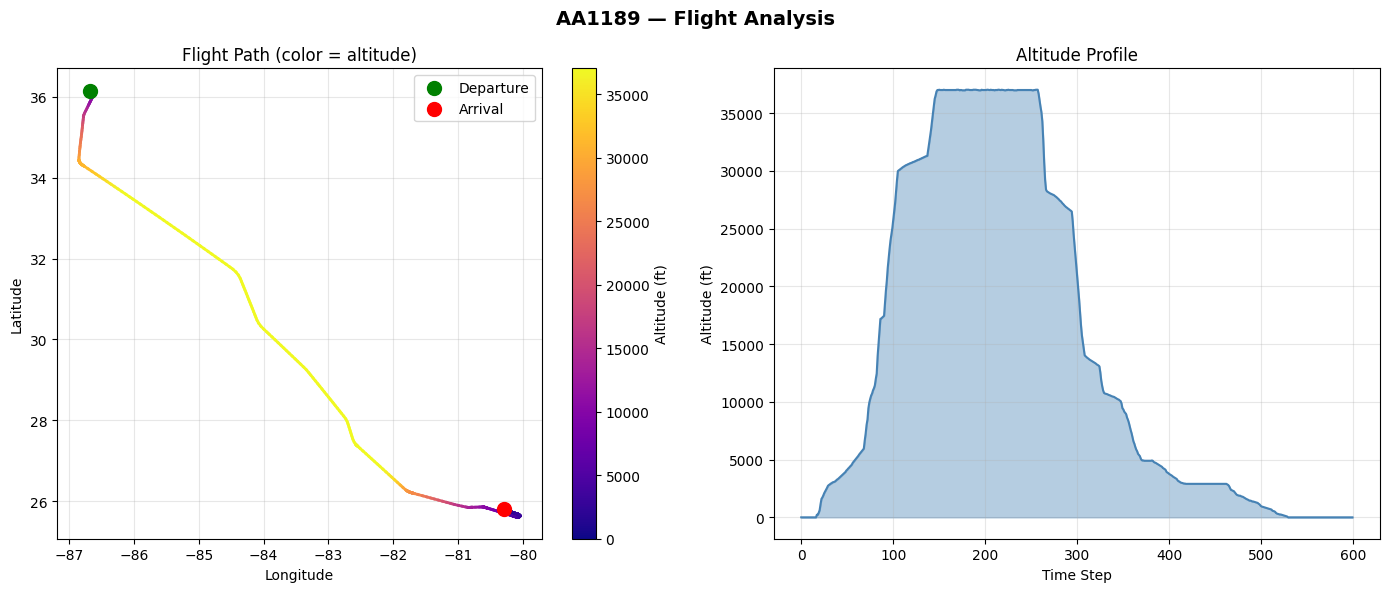

Saved → flight_static.png


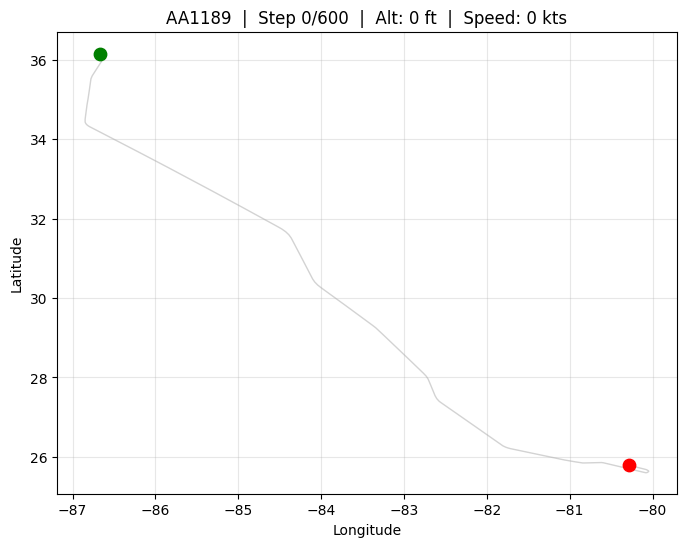

In [95]:
#  STATIC PLOT 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('AA1189 — Flight Analysis', fontsize=14, fontweight='bold')

# Left plot — flight path colored by altitude
ax1 = axes[0]
alt_norm = (df['Altitude'] - df['Altitude'].min()) / (df['Altitude'].max() - df['Altitude'].min())
colors = cm.plasma(alt_norm)

for i in range(len(df) - 1):
    ax1.plot(df['lon'].iloc[i:i+2], df['lat'].iloc[i:i+2], color=colors[i], linewidth=2)

ax1.scatter(df['lon'].iloc[0],  df['lat'].iloc[0],  color='green', s=100, zorder=5, label='Departure')
ax1.scatter(df['lon'].iloc[-1], df['lat'].iloc[-1], color='red',   s=100, zorder=5, label='Arrival')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(df['Altitude'].min(), df['Altitude'].max()))
plt.colorbar(sm, ax=ax1, label='Altitude (ft)')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Flight Path (color = altitude)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot — altitude over time
ax2 = axes[1]
ax2.fill_between(range(len(df)), df['Altitude'], alpha=0.4, color='steelblue')
ax2.plot(range(len(df)), df['Altitude'], color='steelblue', linewidth=1.5)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Altitude (ft)')
ax2.set_title('Altitude Profile')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('flight_static.png', dpi=150)
plt.show()
print("Saved → flight_static.png")


# ANIMATED PLOT 
fig2, ax = plt.subplots(figsize=(8, 6))
plt.ion()

ax.plot(df['lon'], df['lat'], color='lightgrey', linewidth=1, zorder=1)  # ghost path
trail, = ax.plot([], [], color='steelblue', linewidth=2, zorder=2)
dot,   = ax.plot([], [], 'ro', markersize=8, zorder=3)

ax.scatter(df['lon'].iloc[0],  df['lat'].iloc[0],  color='green', s=80, zorder=4)
ax.scatter(df['lon'].iloc[-1], df['lat'].iloc[-1], color='red',   s=80, zorder=4)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

SKIP = 3   # animate every 3rd point- increase to go faster

for i in range(0, len(df), SKIP):
    trail.set_data(df['lon'][:i], df['lat'][:i])
    dot.set_data([df['lon'].iloc[i]], [df['lat'].iloc[i]])
    ax.set_title(f"AA1189  |  Step {i}/{len(df)}  |  Alt: {df['Altitude'].iloc[i]:,} ft  |  Speed: {df['Speed'].iloc[i]} kts")
    plt.pause(0.02)

plt.ioff()
#plt.savefig('flight_animated_final.png', dpi=150)
plt.show()

plot geo graph ---> ai

advance

In [96]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import os, webbrowser

# ── LOAD DATA ────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\Dev Sharma\OneDrive\Documents\MDP\Datasets\Single_AA1189.csv")
df[['lat', 'lon']] = df['Position'].str.split(',', expand=True).astype(float)
df['UTC'] = pd.to_datetime(df['UTC'])
df = df.sort_values('UTC').reset_index(drop=True)

# ── COMPUTE STATS ─────────────────────────────────────────────
duration_min = int((df['UTC'].iloc[-1] - df['UTC'].iloc[0]).total_seconds() / 60)
hours, mins  = divmod(duration_min, 60)
max_alt      = int(df['Altitude'].max())
avg_speed    = int(df['Speed'].mean())
max_speed    = int(df['Speed'].max())
start_time   = df['UTC'].iloc[0].strftime('%H:%M UTC')
end_time     = df['UTC'].iloc[-1].strftime('%H:%M UTC')
start_coord  = f"{df['lat'].iloc[0]:.2f}°N  {abs(df['lon'].iloc[0]):.2f}°W"
end_coord    = f"{df['lat'].iloc[-1]:.2f}°N  {abs(df['lon'].iloc[-1]):.2f}°W"

# Rough distance (haversine)
R = 3440  # nautical miles
lat1, lon1 = np.radians(df['lat'].iloc[0]),  np.radians(df['lon'].iloc[0])
lat2, lon2 = np.radians(df['lat'].iloc[-1]), np.radians(df['lon'].iloc[-1])
dlat, dlon = lat2 - lat1, lon2 - lon1
a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
dist_nm = int(2 * R * np.arcsin(np.sqrt(a)))

# ── BUILD PLOTLY FIGURE ───────────────────────────────────────
fig = go.Figure()

# ---- gradient path segments colored by altitude ----
alt_min, alt_max = df['Altitude'].min(), df['Altitude'].max()

fig.add_trace(go.Scattergeo(
    lat=df['lat'], lon=df['lon'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['Altitude'],
        colorscale=[
            [0.00, '#0a0f2e'],
            [0.20, '#1a3a8f'],
            [0.45, '#0077cc'],
            [0.70, '#00c8e0'],
            [0.88, '#a0f0ff'],
            [1.00, '#ffffff'],
        ],
        cmin=alt_min, cmax=alt_max,
        colorbar=dict(
            title=dict(text='ALTITUDE<br>(ft)', font=dict(color='#7ab8d4', size=10, family='Courier New')),
            tickfont=dict(color='#7ab8d4', size=9, family='Courier New'),
            tickvals=[0, 10000, 20000, 30000, 37000],
            ticktext=['0', '10k', '20k', '30k', '37k'],
            thickness=10,
            len=0.5,
            x=0.01,
            xanchor='left',
            y=0.5,
            yanchor='middle',
            bgcolor='rgba(5,12,28,0.85)',
            bordercolor='rgba(0,180,220,0.3)',
            borderwidth=1,
            outlinewidth=0,
        ),
        showscale=True,
        opacity=0.95,
        line=dict(width=0),
    ),
    text=[
        f"<b>AA1189</b><br>"
        f"──────────────<br>"
        f"⏱  {r.UTC.strftime('%H:%M:%S')} UTC<br>"
        f"📍 {r.lat:.4f}°N  {abs(r.lon):.4f}°W<br>"
        f"✈  {int(r.Altitude):,} ft<br>"
        f"💨 {int(r.Speed)} kts<br>"
        f"🧭 {int(r.Direction)}°"
        for _, r in df.iterrows()
    ],
    hoverinfo='text',
    hoverlabel=dict(
        bgcolor='#050c1c',
        bordercolor='#00c8e0',
        font=dict(color='#c8eaf5', size=12, family='Courier New'),
    ),
    name='Flight Path',
    showlegend=False,
))

# ---- thin connecting line ----
fig.add_trace(go.Scattergeo(
    lat=df['lat'], lon=df['lon'],
    mode='lines',
    line=dict(width=1.5, color='rgba(0,180,220,0.25)'),
    hoverinfo='skip',
    showlegend=False,
))

# ---- departure marker ----
fig.add_trace(go.Scattergeo(
    lat=[df['lat'].iloc[0]], lon=[df['lon'].iloc[0]],
    mode='markers',
    marker=dict(size=16, color='#00ff9d', symbol='circle',
                line=dict(color='white', width=2)),
    hovertext=f"<b>DEPARTURE</b><br>Nashville, TN<br>{start_coord}<br>{start_time}",
    hoverinfo='text',
    hoverlabel=dict(bgcolor='#050c1c', bordercolor='#00ff9d',
                    font=dict(color='#00ff9d', size=12, family='Courier New')),
    name='Departure',
    showlegend=False,
))

# ---- arrival marker ----
fig.add_trace(go.Scattergeo(
    lat=[df['lat'].iloc[-1]], lon=[df['lon'].iloc[-1]],
    mode='markers',
    marker=dict(size=16, color='#ff4455', symbol='square',
                line=dict(color='white', width=2)),
    hovertext=f"<b>ARRIVAL</b><br>Miami, FL<br>{end_coord}<br>{end_time}",
    hoverinfo='text',
    hoverlabel=dict(bgcolor='#050c1c', bordercolor='#ff4455',
                    font=dict(color='#ff4455', size=12, family='Courier New')),
    name='Arrival',
    showlegend=False,
))

# ── GEO STYLING ───────────────────────────────────────────────
mid_lat = (df['lat'].max() + df['lat'].min()) / 2
mid_lon = (df['lon'].max() + df['lon'].min()) / 2

fig.update_geos(
    projection=dict(
        type='orthographic',
        rotation=dict(lon=mid_lon, lat=mid_lat),
    ),
    center=dict(lat=mid_lat, lon=mid_lon),
    showland=True,      landcolor='#0d1b2a',
    showocean=True,     oceancolor='#060d1a',
    showlakes=True,     lakecolor='#081422',
    showcountries=True, countrycolor='rgba(60,100,160,0.5)',  countrywidth=0.6,
    showcoastlines=True,coastlinecolor='rgba(0,140,200,0.7)', coastlinewidth=1,
    showsubunits=True,  subunitcolor='rgba(40,80,130,0.4)',   subunitwidth=0.5,
    showrivers=False,
    lonaxis=dict(range=[df['lon'].min() - 4, df['lon'].max() + 4]),
    lataxis=dict(range=[df['lat'].min() - 4, df['lat'].max() + 4]),
    bgcolor='#030810',
)

fig.update_layout(
    paper_bgcolor='#030810',
    geo_bgcolor='#030810',
    margin=dict(l=0, r=0, t=0, b=0),
    height=700,
    showlegend=False,
)

# ── EXPORT PLOTLY AS EMBEDDABLE DIV ──────────────────────────
plotly_div = fig.to_html(full_html=False, include_plotlyjs='cdn', config={
    'displaylogo': False,
    'modeBarButtonsToRemove': ['select2d', 'lasso2d'],
    'scrollZoom': True,
})

# ── BUILD FULL HTML DASHBOARD ─────────────────────────────────
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>AA1189 Flight Tracker</title>
  <link rel="preconnect" href="https://fonts.googleapis.com">
  <link href="https://fonts.googleapis.com/css2?family=Share+Tech+Mono&family=Rajdhani:wght@300;400;600;700&display=swap" rel="stylesheet">
  <style>
    *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}

    :root {{
      --bg:       #030810;
      --panel:    rgba(5, 14, 30, 0.92);
      --border:   rgba(0, 180, 220, 0.22);
      --cyan:     #00c8e0;
      --cyan-dim: rgba(0, 200, 224, 0.55);
      --green:    #00ff9d;
      --red:      #ff4455;
      --text:     #c8eaf5;
      --muted:    #4a7a92;
      --mono:     'Share Tech Mono', monospace;
      --head:     'Rajdhani', sans-serif;
    }}

    html, body {{
      width: 100%; height: 100%;
      background: var(--bg);
      color: var(--text);
      font-family: var(--head);
      overflow: hidden;
    }}

    /* ── scanline overlay ── */
    body::before {{
      content: '';
      position: fixed; inset: 0;
      background: repeating-linear-gradient(
        0deg,
        transparent,
        transparent 2px,
        rgba(0,0,0,0.04) 2px,
        rgba(0,0,0,0.04) 4px
      );
      pointer-events: none;
      z-index: 999;
    }}

    /* ── corner glow ── */
    body::after {{
      content: '';
      position: fixed; inset: 0;
      background:
        radial-gradient(ellipse 60% 40% at 50% 50%, rgba(0,80,140,0.08) 0%, transparent 70%);
      pointer-events: none;
      z-index: 0;
    }}

    /* ── TOP BAR ── */
    header {{
      position: fixed; top: 0; left: 0; right: 0; z-index: 100;
      height: 52px;
      display: flex; align-items: center; justify-content: space-between;
      padding: 0 20px;
      background: rgba(3,8,16,0.96);
      border-bottom: 1px solid var(--border);
      backdrop-filter: blur(12px);
    }}
    .header-left {{
      display: flex; align-items: center; gap: 14px;
    }}
    .callsign {{
      font-family: var(--mono);
      font-size: 22px;
      color: var(--cyan);
      letter-spacing: 3px;
      text-shadow: 0 0 18px rgba(0,200,224,0.6);
    }}
    .badge {{
      font-family: var(--mono);
      font-size: 10px;
      color: var(--muted);
      background: rgba(0,180,220,0.08);
      border: 1px solid var(--border);
      padding: 3px 8px;
      letter-spacing: 2px;
      text-transform: uppercase;
    }}
    .header-right {{
      font-family: var(--mono);
      font-size: 11px;
      color: var(--muted);
      letter-spacing: 1px;
    }}
    .live-dot {{
      display: inline-block;
      width: 7px; height: 7px;
      border-radius: 50%;
      background: var(--green);
      margin-right: 6px;
      box-shadow: 0 0 8px var(--green);
      animation: pulse 1.8s ease-in-out infinite;
    }}
    @keyframes pulse {{
      0%, 100% {{ opacity: 1; transform: scale(1); }}
      50%       {{ opacity: 0.4; transform: scale(0.7); }}
    }}

    /* ── MAP WRAPPER ── */
    #map-container {{
      position: fixed; inset: 52px 0 0 0;
      z-index: 1;
    }}
    #map-container > div {{
      width: 100% !important;
      height: 100% !important;
    }}

    /* ── PANELS base ── */
    .panel {{
      position: fixed;
      z-index: 50;
      background: var(--panel);
      border: 1px solid var(--border);
      backdrop-filter: blur(16px);
      padding: 14px 16px;
    }}
    .panel-title {{
      font-family: var(--mono);
      font-size: 9px;
      letter-spacing: 3px;
      color: var(--muted);
      text-transform: uppercase;
      margin-bottom: 12px;
      padding-bottom: 8px;
      border-bottom: 1px solid rgba(0,180,220,0.15);
    }}

    /* ── LEFT PANEL — flight stats ── */
    #panel-stats {{
      top: 68px; left: 14px;
      width: 210px;
    }}
    .stat-row {{
      display: flex;
      justify-content: space-between;
      align-items: baseline;
      margin-bottom: 10px;
    }}
    .stat-label {{
      font-family: var(--mono);
      font-size: 9px;
      color: var(--muted);
      letter-spacing: 1.5px;
      text-transform: uppercase;
    }}
    .stat-value {{
      font-family: var(--mono);
      font-size: 14px;
      color: var(--text);
      text-align: right;
    }}
    .stat-value.big {{
      font-size: 18px;
      color: var(--cyan);
      text-shadow: 0 0 12px rgba(0,200,224,0.4);
    }}
    .stat-value.green {{ color: var(--green); }}
    .stat-value.red   {{ color: var(--red);   }}

    /* altitude mini-bar */
    .alt-bar-track {{
      width: 100%;
      height: 3px;
      background: rgba(0,180,220,0.12);
      margin-top: 4px;
      margin-bottom: 10px;
    }}
    .alt-bar-fill {{
      height: 3px;
      background: linear-gradient(90deg, #0077cc, #00c8e0, #ffffff);
      width: {min(int(max_alt / 45000 * 100), 100)}%;
    }}

    /* ── BOTTOM PANEL — route ── */
    #panel-route {{
      bottom: 16px; left: 50%;
      transform: translateX(-50%);
      width: 480px;
      padding: 12px 20px;
    }}
    .route-row {{
      display: flex;
      align-items: center;
      justify-content: space-between;
      gap: 12px;
    }}
    .route-airport {{
      text-align: center;
    }}
    .airport-code {{
      font-family: var(--head);
      font-size: 26px;
      font-weight: 700;
      letter-spacing: 2px;
      color: var(--text);
    }}
    .airport-name {{
      font-family: var(--mono);
      font-size: 9px;
      color: var(--muted);
      letter-spacing: 1px;
      margin-top: 2px;
    }}
    .airport-time {{
      font-family: var(--mono);
      font-size: 11px;
      margin-top: 4px;
    }}
    .route-line {{
      flex: 1;
      display: flex;
      flex-direction: column;
      align-items: center;
      gap: 4px;
    }}
    .route-line-bar {{
      width: 100%;
      height: 1px;
      background: linear-gradient(90deg, var(--green), var(--cyan), var(--red));
      position: relative;
    }}
    .route-line-bar::after {{
      content: '✈';
      position: absolute;
      top: -8px; left: 50%;
      transform: translateX(-50%);
      font-size: 13px;
      color: var(--cyan);
      text-shadow: 0 0 10px var(--cyan);
    }}
    .route-dist {{
      font-family: var(--mono);
      font-size: 10px;
      color: var(--muted);
      letter-spacing: 1px;
    }}

    /* ── RIGHT PANEL — legend ── */
    #panel-legend {{
      top: 68px; right: 14px;
      width: 170px;
    }}
    .legend-item {{
      display: flex;
      align-items: center;
      gap: 10px;
      margin-bottom: 9px;
    }}
    .legend-dot {{
      width: 12px; height: 12px;
      border-radius: 50%;
      flex-shrink: 0;
    }}
    .legend-sq {{
      width: 12px; height: 12px;
      flex-shrink: 0;
    }}
    .legend-line {{
      width: 28px; height: 3px;
      flex-shrink: 0;
    }}
    .legend-label {{
      font-family: var(--mono);
      font-size: 10px;
      color: var(--text);
      letter-spacing: 0.5px;
    }}
    .alt-gradient-bar {{
      width: 100%;
      height: 8px;
      border-radius: 2px;
      background: linear-gradient(90deg, #0a0f2e, #0077cc, #00c8e0, #ffffff);
      margin: 6px 0 2px;
    }}
    .alt-gradient-labels {{
      display: flex;
      justify-content: space-between;
      font-family: var(--mono);
      font-size: 8px;
      color: var(--muted);
    }}

    /* ── CORNER DECORATORS ── */
    .corner {{
      position: fixed; z-index: 60;
      width: 20px; height: 20px;
    }}
    .corner-tl {{ top: 58px;  left:  8px;  border-top: 1px solid var(--cyan-dim); border-left:  1px solid var(--cyan-dim); }}
    .corner-tr {{ top: 58px;  right: 8px;  border-top: 1px solid var(--cyan-dim); border-right: 1px solid var(--cyan-dim); }}
    .corner-bl {{ bottom: 8px; left:  8px; border-bottom: 1px solid var(--cyan-dim); border-left:  1px solid var(--cyan-dim); }}
    .corner-br {{ bottom: 8px; right: 8px; border-bottom: 1px solid var(--cyan-dim); border-right: 1px solid var(--cyan-dim); }}

    /* fade-in on load */
    .panel {{ animation: fadein 0.8s ease both; }}
    #panel-stats  {{ animation-delay: 0.1s; }}
    #panel-legend {{ animation-delay: 0.2s; }}
    #panel-route  {{ animation-delay: 0.3s; }}
    @keyframes fadein {{
      from {{ opacity: 0; transform: translateY(6px); }}
      to   {{ opacity: 1; transform: translateY(0);   }}
    }}
  </style>
</head>
<body>

  <!-- TOP BAR -->
  <header>
    <div class="header-left">
      <span class="callsign">AA1189</span>
      <span class="badge">American Airlines</span>
      <span class="badge">B737</span>
    </div>
    <div class="header-right">
      <span class="live-dot"></span>
      REPLAY &nbsp;|&nbsp; {df['UTC'].iloc[0].strftime('%d %b %Y')} &nbsp;|&nbsp; {len(df)} DATA POINTS
    </div>
  </header>

  <!-- MAP -->
  <div id="map-container">
    {plotly_div}
  </div>

  <!-- CORNER DECORATORS -->
  <div class="corner corner-tl"></div>
  <div class="corner corner-tr"></div>
  <div class="corner corner-bl"></div>
  <div class="corner corner-br"></div>

  <!-- LEFT PANEL — FLIGHT STATS -->
  <div class="panel" id="panel-stats">
    <div class="panel-title">▸ Flight Statistics</div>

    <div class="stat-row">
      <span class="stat-label">Max Altitude</span>
      <span class="stat-value big">{max_alt:,} ft</span>
    </div>
    <div class="alt-bar-track"><div class="alt-bar-fill"></div></div>

    <div class="stat-row">
      <span class="stat-label">Avg Speed</span>
      <span class="stat-value">{avg_speed} kts</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">Max Speed</span>
      <span class="stat-value">{max_speed} kts</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">Duration</span>
      <span class="stat-value">{hours}h {mins:02d}m</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">Distance</span>
      <span class="stat-value">{dist_nm} nm</span>
    </div>
    <div class="stat-row">
      <span class="stat-label">Data Points</span>
      <span class="stat-value">{len(df)}</span>
    </div>

    <div style="margin-top:10px; padding-top:10px; border-top: 1px solid rgba(0,180,220,0.12);">
      <div class="stat-row">
        <span class="stat-label">Departure</span>
        <span class="stat-value green" style="font-size:10px;">{start_coord}</span>
      </div>
      <div class="stat-row">
        <span class="stat-label">Arrival</span>
        <span class="stat-value red" style="font-size:10px;">{end_coord}</span>
      </div>
    </div>
  </div>

  <!-- RIGHT PANEL — LEGEND -->
  <div class="panel" id="panel-legend">
    <div class="panel-title">▸ Legend</div>

    <div class="legend-item">
      <div class="legend-dot" style="background:#00ff9d; box-shadow: 0 0 8px #00ff9d;"></div>
      <span class="legend-label">Departure</span>
    </div>
    <div class="legend-item">
      <div class="legend-sq" style="background:#ff4455; box-shadow: 0 0 8px #ff4455;"></div>
      <span class="legend-label">Arrival</span>
    </div>
    <div class="legend-item">
      <div class="legend-line" style="background: linear-gradient(90deg,#0077cc,#00c8e0);"></div>
      <span class="legend-label">Flight Path</span>
    </div>

    <div style="margin-top:12px; padding-top:10px; border-top:1px solid rgba(0,180,220,0.12);">
      <div class="panel-title" style="margin-bottom:6px;">▸ Altitude Scale</div>
      <div class="alt-gradient-bar"></div>
      <div class="alt-gradient-labels">
        <span>0 ft</span>
        <span>37k ft</span>
      </div>
    </div>

    <div style="margin-top:12px; padding-top:10px; border-top:1px solid rgba(0,180,220,0.12);">
      <div class="panel-title" style="margin-bottom:6px;">▸ Controls</div>
      <div style="font-family: var(--mono); font-size:9px; color:var(--muted); line-height:1.8;">
        DRAG  → rotate globe<br>
        SCROLL → zoom<br>
        HOVER  → point details
      </div>
    </div>
  </div>

  <!-- BOTTOM PANEL — ROUTE -->
  <div class="panel" id="panel-route">
    <div class="route-row">
      <div class="route-airport">
        <div class="airport-code">BNA</div>
        <div class="airport-name">Nashville Int'l</div>
        <div class="airport-time" style="color:var(--green);">{start_time}</div>
      </div>
      <div class="route-line">
        <div class="route-line-bar"></div>
        <div class="route-dist">{dist_nm} nm &nbsp;·&nbsp; {hours}h {mins:02d}m</div>
      </div>
      <div class="route-airport">
        <div class="airport-code">MIA</div>
        <div class="airport-name">Miami Int'l</div>
        <div class="airport-time" style="color:var(--red);">{end_time}</div>
      </div>
    </div>
  </div>

</body>
</html>"""

# ── SAVE & OPEN ───────────────────────────────────────────────
out = 'flight_dashboard.html'
with open(out, 'w', encoding='utf-8') as f:
    f.write(html)

print(f"✈  Saved → {out}")
webbrowser.open('file://' + os.path.abspath(out))

✈  Saved → flight_dashboard.html


True